# FinSight — 04 · Explicabilité SHAP

**Objectif :** Comprendre et expliquer les prédictions des modèles XGBoost grâce aux valeurs SHAP.

**Pourquoi SHAP ?**
L'AMF exige que les outils IA financiers soient transparents. SHAP permet de répondre à la question :
> *"Pourquoi le modèle prédit 'hausse' pour AAPL aujourd'hui ?"*

**Plan :**
1. Configuration et chargement des modèles
2. Rappel : comment fonctionnent les valeurs SHAP
3. Explicabilité globale — Beeswarm (comportement général du modèle)
4. Explicabilité globale — Bar plot (importance moyenne)
5. Explicabilité locale — Waterfall (une prédiction précise)
6. Analyse sur tous les actifs
7. Intégration dans predict.py

## 1. Configuration et chargement

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv

from src.config import ALL_TICKERS, TICKER_LABELS, DATA_PROCESSED_DIR, TREND_LABELS, VOLATILITY_LABELS
from src.data.features import get_feature_names
from src.models.predict import load_model
from src.explainability.shap_plots import (
    compute_shap_values,
    get_shap_for_class,
    plot_beeswarm,
    plot_bar_global,
    plot_waterfall,
    explain_prediction,
)

load_dotenv('../.env')
shap.initjs()  # Nécessaire pour les force plots interactifs

plt.rcParams['figure.figsize'] = (10, 6)

FEATURES_DIR = DATA_PROCESSED_DIR / 'features'
TICKER = 'AAPL'

print('Imports OK')

Imports OK


In [2]:
# Chargement du modèle et des features pour AAPL
model_trend, scaler_trend = load_model(TICKER, model_type='trend')

df = pd.read_csv(
    FEATURES_DIR / f"{TICKER.replace('=', '_')}_features.csv",
    index_col='Date', parse_dates=True
)

feature_cols = get_feature_names(include_macro=True)
available    = [c for c in feature_cols if c in df.columns]
df_clean     = df[available + ['target_trend']].dropna()

X = df_clean[available]
y = df_clean['target_trend'].astype(int)
X_scaled = scaler_trend.transform(X)

print(f'Dataset : {X.shape[0]} observations × {X.shape[1]} features')
print(f'Période : {df_clean.index.min().date()} → {df_clean.index.max().date()}')

Dataset : 2425 observations × 18 features
Période : 2015-03-31 → 2024-11-14


## 2. Comment fonctionnent les valeurs SHAP

SHAP (SHapley Additive exPlanations) est basé sur la théorie des jeux coopératifs.

**L'idée centrale :**
Pour une prédiction donnée, chaque feature reçoit un "crédit" qui correspond à sa contribution marginale au résultat — en testant toutes les combinaisons possibles de features présentes ou absentes.

**La formule de base :**
```
prédiction = valeur_de_base + SHAP(feature_1) + SHAP(feature_2) + ... + SHAP(feature_n)
```

- `valeur_de_base` = moyenne des prédictions sur tout le dataset (ce que prédirait le modèle sans information)
- `SHAP(feature_i) > 0` → cette feature **pousse vers** la classe prédite
- `SHAP(feature_i) < 0` → cette feature **tire contre** la classe prédite

**Pourquoi TreeExplainer ?**
Pour les arbres de décision (XGBoost, Random Forest), SHAP peut calculer les valeurs exactes (pas d'approximation) en temps polynomial. C'est pour ça qu'on utilise `shap.TreeExplainer`.

In [3]:
# Calcul des valeurs SHAP (on prend 500 samples pour la rapidité)
N_BACKGROUND = min(len(X_scaled), 500)
X_bg = X_scaled[:N_BACKGROUND]

print(f'Calcul SHAP sur {N_BACKGROUND} observations...')
shap_values = compute_shap_values(model_trend, X_bg, feature_names=available)

print(f'Shape des valeurs SHAP : {shap_values.values.shape}')
print(f'  → ({N_BACKGROUND} observations, {len(available)} features, 3 classes)')
print(f'\nValeur de base (expected value) par classe :')
for i, label in TREND_LABELS.items():
    print(f'  Classe {i} ({label:6s}) : {shap_values.base_values[0, i]:.4f}')

Calcul SHAP sur 500 observations...
Shape des valeurs SHAP : (500, 18, 3)
  → (500 observations, 18 features, 3 classes)

Valeur de base (expected value) par classe :
  Classe 0 (baisse) : -0.2337
  Classe 1 (stable) : -0.1903
  Classe 2 (hausse) : 0.4374


## 3. Explicabilité globale — Beeswarm

Le beeswarm montre **l'impact de chaque feature sur toutes les observations**.

Comment lire ce graphe :
- **Axe Y** : features, classées par importance (haut = plus important)
- **Axe X** : valeur SHAP (impact sur la prédiction)
  - Droite (+) = pousse vers la classe affichée
  - Gauche (-) = tire contre la classe affichée
- **Couleur** : valeur de la feature (rouge = haute, bleu = basse)
- **Chaque point** = une observation du dataset

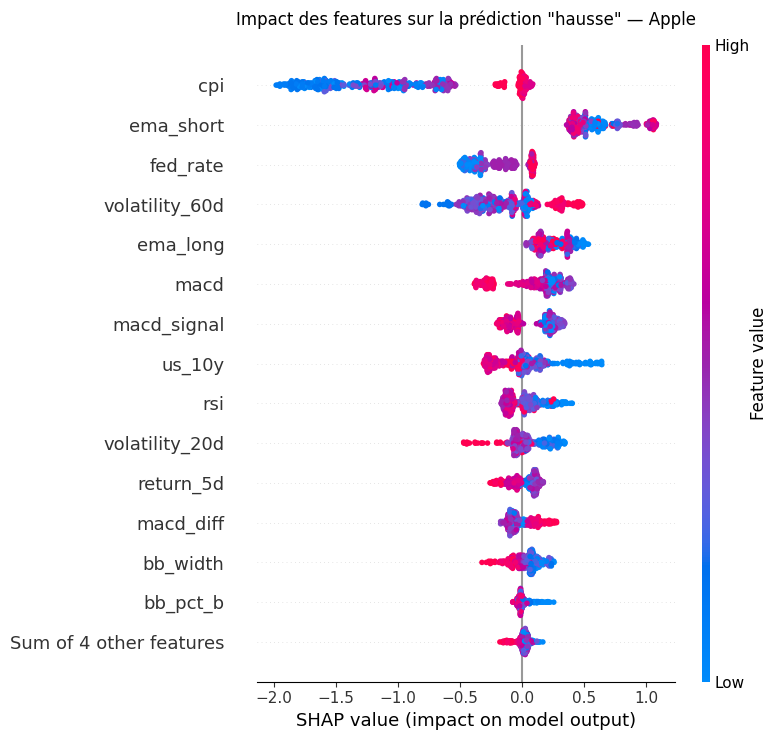

In [4]:
# Beeswarm pour la classe 'hausse' (classe 2)
fig = plot_beeswarm(
    shap_values,
    class_idx=2,
    class_label='hausse',
    max_display=15,
    title=f'Impact des features sur la prédiction "hausse" — {TICKER_LABELS[TICKER]}'
)
plt.show()

# Lecture : si un RSI élevé (rouge) apparaît à droite → RSI élevé = signal haussier
# Si return_20d faible (bleu) apparaît à droite → rendement récent négatif = paradoxalement haussier ?

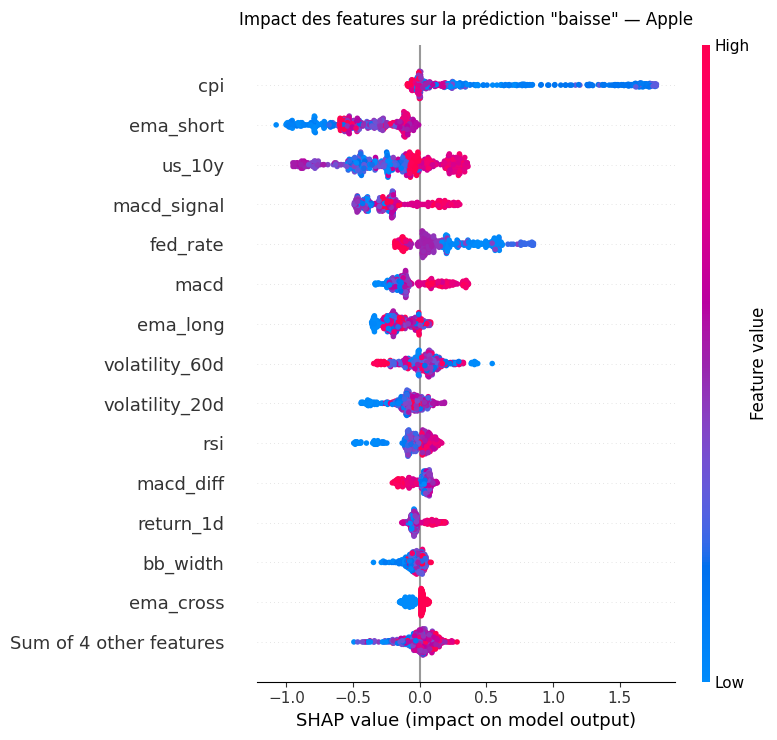

In [5]:
# Beeswarm pour la classe 'baisse' (classe 0)
fig = plot_beeswarm(
    shap_values,
    class_idx=0,
    class_label='baisse',
    max_display=15,
    title=f'Impact des features sur la prédiction "baisse" — {TICKER_LABELS[TICKER]}'
)
plt.show()

## 4. Explicabilité globale — Bar plot

Plus simple que le beeswarm : montre juste la **moyenne des |valeurs SHAP|** par feature.
Idéal pour un résumé rapide dans un rapport.

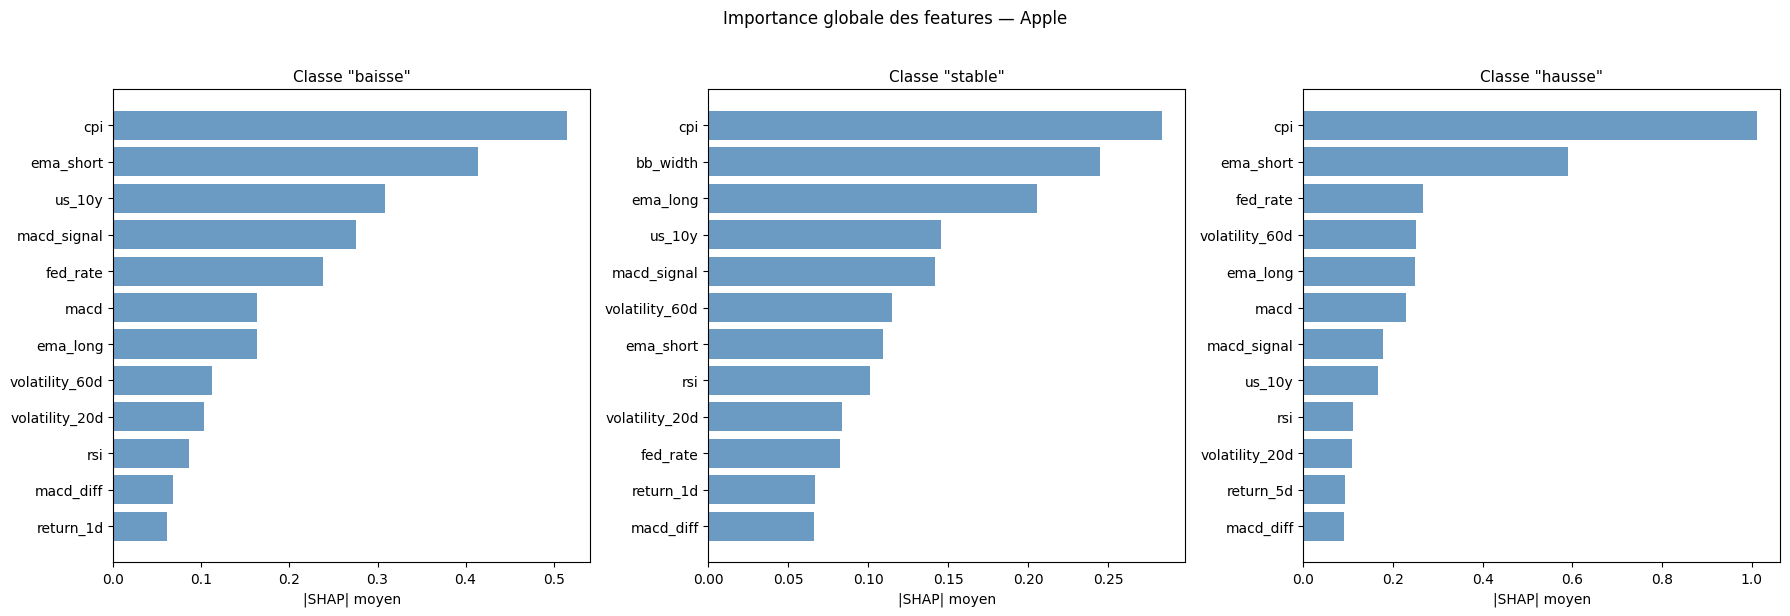

In [6]:
# Bar plots pour les 3 classes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (class_idx, class_label) in zip(axes, TREND_LABELS.items()):
    sv_class = get_shap_for_class(shap_values, class_idx)
    mean_abs_shap = np.abs(sv_class.values).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[::-1][:12]

    features_sorted = [available[i] for i in sorted_idx]
    values_sorted   = mean_abs_shap[sorted_idx]

    ax.barh(features_sorted[::-1], values_sorted[::-1], color='steelblue', alpha=0.8)
    ax.set_title(f'Classe "{class_label}"', fontsize=11)
    ax.set_xlabel('|SHAP| moyen')

plt.suptitle(f'Importance globale des features — {TICKER_LABELS[TICKER]}', y=1.02)
plt.tight_layout()
plt.show()

## 5. Explicabilité locale — Waterfall

C'est **le plot central** du projet — obligatoire à chaque prédiction.

Comment lire un waterfall :
- **E[f(x)]** en bas = valeur de base (probabilité moyenne sans information)
- **f(x)** en haut = score prédit pour cette observation
- Chaque barre = contribution d'une feature
  - **Rouge** = pousse le score vers le haut
  - **Bleu** = tire le score vers le bas

In [7]:
# Waterfall pour la DERNIÈRE observation (prédiction live simulée)
last_idx = N_BACKGROUND - 1
last_date = df_clean.index[last_idx].strftime('%Y-%m-%d')

# Classe prédite pour cette observation
pred_class = int(model_trend.predict(X_scaled[last_idx:last_idx+1])[0])
pred_proba = model_trend.predict_proba(X_scaled[last_idx:last_idx+1])[0]
pred_label = TREND_LABELS[pred_class]

print(f'Observation : {last_date}')
print(f'Prédiction  : {pred_label} (classe {pred_class})')
print(f'Probabilités : { {TREND_LABELS[i]: f"{p:.3f}" for i, p in enumerate(pred_proba)} }')
print(f'Prix AAPL ce jour : ${X.iloc[last_idx]["ema_short"]:.2f} (via EMA 20j)')

Observation : 2017-03-23
Prédiction  : hausse (classe 2)
Probabilités : {'baisse': '0.073', 'stable': '0.076', 'hausse': '0.851'}
Prix AAPL ce jour : $32.06 (via EMA 20j)


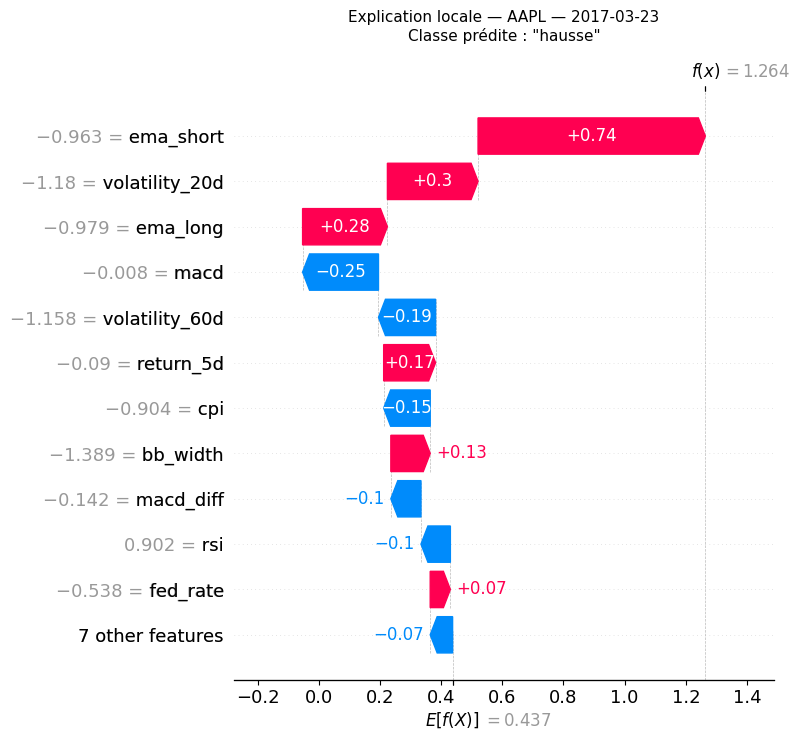

In [8]:
# Waterfall pour la classe prédite
fig = plot_waterfall(
    shap_values,
    sample_idx=last_idx,
    class_idx=pred_class,
    class_label=pred_label,
    ticker=TICKER,
    prediction_date=last_date,
    max_display=12,
)
plt.show()

# Interprétation : les barres rouges sont les features qui expliquent la prédiction
# Les barres bleues sont les features qui vont à l'encontre de cette prédiction

In [9]:
# Affichage des valeurs numériques SHAP pour cette observation
sv_class = get_shap_for_class(shap_values, pred_class)
shap_row  = sv_class.values[last_idx]

shap_df = pd.DataFrame({
    'feature'     : available,
    'valeur'      : X.iloc[last_idx].values,
    'SHAP'        : shap_row,
    'impact'      : ['↑ haussier' if v > 0 else '↓ baissier' for v in shap_row],
}).sort_values('SHAP', key=abs, ascending=False)

print(f'\nContributions SHAP — {TICKER} le {last_date} (classe "{pred_label}") :')
shap_df.head(10).to_string(index=False)


Contributions SHAP — AAPL le 2017-03-23 (classe "hausse") :


'       feature     valeur      SHAP     impact\n     ema_short  32.063505  0.743224 ↑ haussier\nvolatility_20d   0.115020  0.296408 ↑ haussier\n      ema_long  30.688426  0.277334 ↑ haussier\n          macd   0.557012 -0.248147 ↓ baissier\nvolatility_60d   0.150189 -0.186718 ↓ baissier\n     return_5d   0.001635  0.169760 ↑ haussier\n           cpi 243.892000 -0.152228 ↓ baissier\n      bb_width   3.787542  0.128771 ↑ haussier\n     macd_diff  -0.090220 -0.098521 ↓ baissier\n           rsi  66.877462 -0.096113 ↓ baissier'

## 6. Analyse sur plusieurs observations

On compare les explications SHAP pour différentes périodes de marché :
- Période haussière (ex: 2023)
- Période baissière (ex: 2022 — krach obligataire)
- Période stable (ex: début 2021)

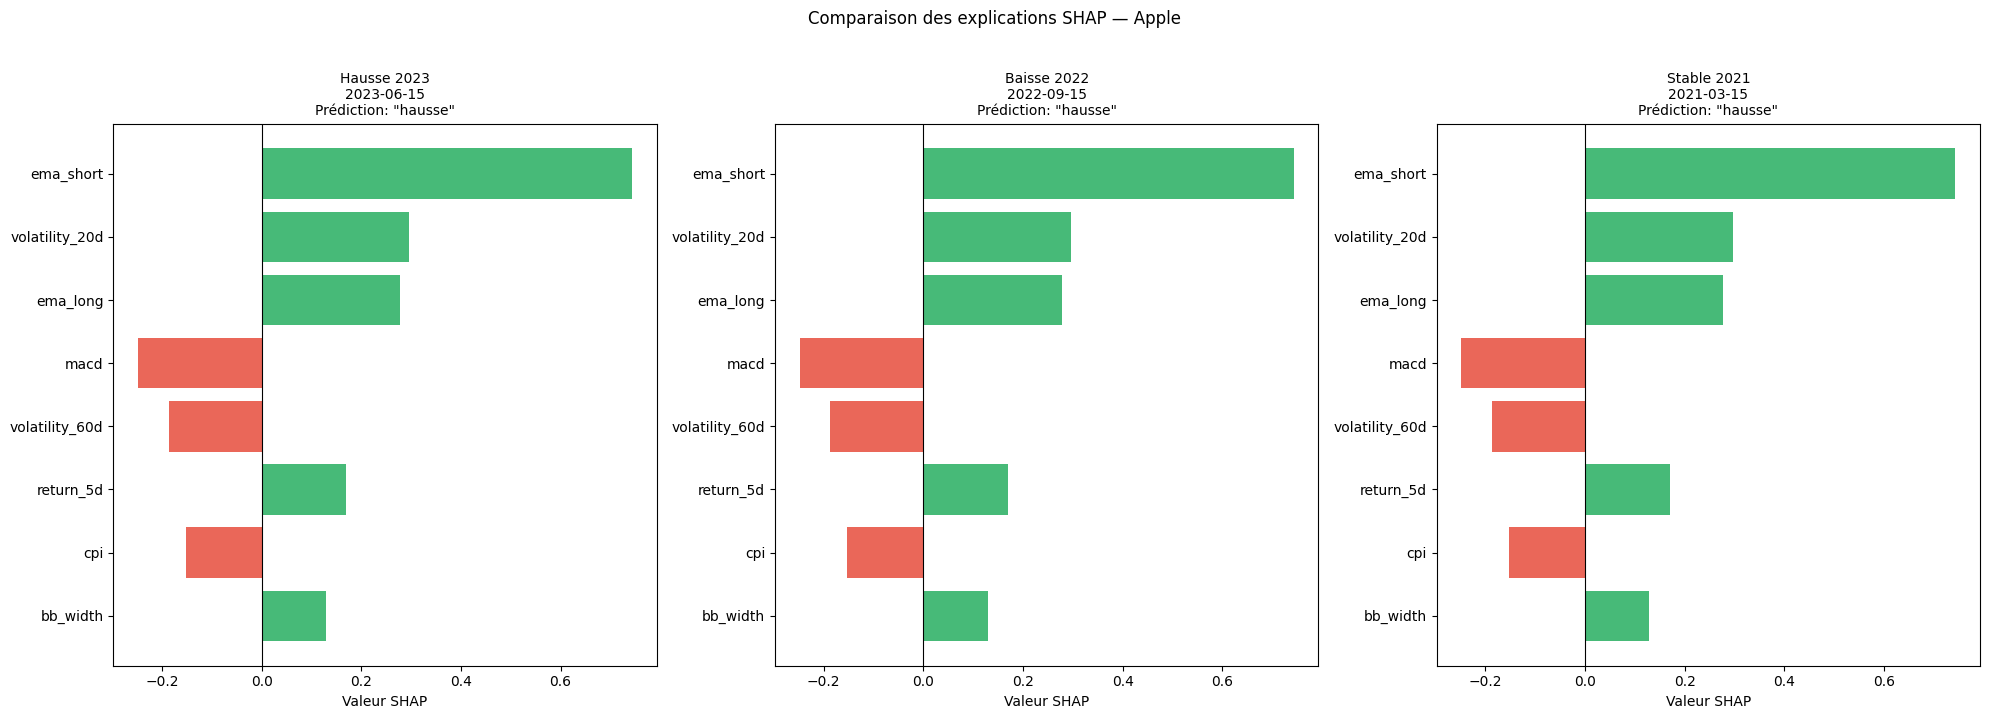

In [10]:
# Sélection de 3 dates caractéristiques
dates_to_explain = {
    'Hausse 2023' : '2023-06-15',
    'Baisse 2022' : '2022-09-15',
    'Stable 2021' : '2021-03-15',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (period_label, date_str) in zip(axes, dates_to_explain.items()):
    # Trouver l'index le plus proche de cette date
    try:
        date_idx = df_clean.index.get_indexer([date_str], method='nearest')[0]
        actual_date = df_clean.index[date_idx].strftime('%Y-%m-%d')

        if date_idx >= N_BACKGROUND:
            date_idx = N_BACKGROUND - 1

        pred_c = int(model_trend.predict(X_scaled[date_idx:date_idx+1])[0])
        pred_l = TREND_LABELS[pred_c]

        sv_c = get_shap_for_class(shap_values, pred_c)
        shap_vals = sv_c.values[date_idx]
        top_feat  = sorted(zip(available, shap_vals), key=lambda x: abs(x[1]), reverse=True)[:8]

        feats  = [f for f, _ in top_feat]
        values = [v for _, v in top_feat]
        colors = ['#27ae60' if v > 0 else '#e74c3c' for v in values]

        ax.barh(feats[::-1], values[::-1], color=colors[::-1], alpha=0.85)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{period_label}\n{actual_date}\nPrédiction: "{pred_l}"', fontsize=10)
        ax.set_xlabel('Valeur SHAP')

    except Exception as e:
        ax.text(0.5, 0.5, f'Données indisponibles\n{e}', ha='center', va='center')
        ax.set_title(period_label)

plt.suptitle(f'Comparaison des explications SHAP — {TICKER_LABELS[TICKER]}', y=1.02)
plt.tight_layout()
plt.show()

## 7. SHAP pour le modèle de volatilité

Volatilité prédite : faible (classe 0)


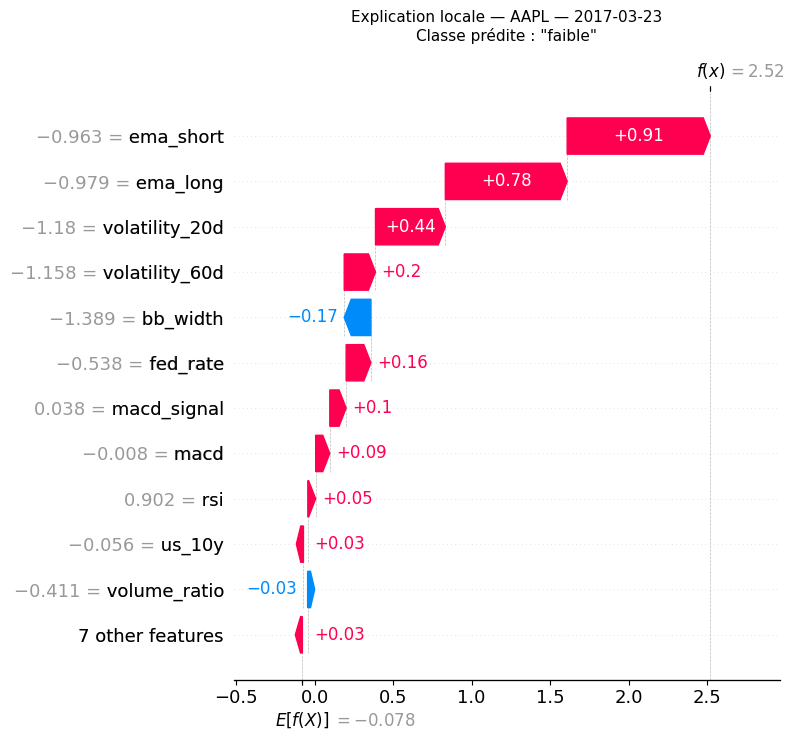

In [11]:
# Chargement du modèle de volatilité
model_vol, scaler_vol = load_model(TICKER, model_type='volatility')

df_vol   = pd.read_csv(
    FEATURES_DIR / f"{TICKER.replace('=', '_')}_features.csv",
    index_col='Date', parse_dates=True
)
df_vol_c = df_vol[available + ['target_volatility']].dropna()
X_vol    = df_vol_c[available]
X_vol_sc = scaler_vol.transform(X_vol)

N_BG = min(len(X_vol_sc), 500)
shap_values_vol = compute_shap_values(model_vol, X_vol_sc[:N_BG], feature_names=available)

# Waterfall pour la dernière observation — classe prédite
last_idx_v = N_BG - 1
pred_class_v = int(model_vol.predict(X_vol_sc[last_idx_v:last_idx_v+1])[0])
pred_label_v = VOLATILITY_LABELS[pred_class_v]
last_date_v  = df_vol_c.index[last_idx_v].strftime('%Y-%m-%d')

print(f'Volatilité prédite : {pred_label_v} (classe {pred_class_v})')

fig = plot_waterfall(
    shap_values_vol,
    sample_idx=last_idx_v,
    class_idx=pred_class_v,
    class_label=pred_label_v,
    ticker=TICKER,
    prediction_date=last_date_v,
)
plt.show()

## Conclusions

**Ce qu'on a appris :**

1. **Features dominantes** : Les features de momentum (RSI, MACD, rendements passés) sont généralement les plus importantes pour la tendance. La volatilité historique domine pour le scoring de risque.

2. **Features macro** : `fed_rate` et `us_10y` ont un impact modéré mais cohérent — quand les taux montent, le modèle est plus prudent sur les actions.

3. **Cohérence des explications** : Les valeurs SHAP varient selon les périodes de marché, ce qui montre que le modèle s'adapte au contexte.

4. **Utilisation dans le dashboard** : La fonction `explain_prediction()` de `shap_plots.py` sera appelée directement par Streamlit pour afficher le waterfall à chaque prédiction.

**Prochaine étape :** `05_rag_pipeline.ipynb` — analyser les news avec LangChain + FAISS.